# Assignment 2: Code Creation and Analysis on Students Performance

**Sofia Rafailia Tilikidou - 2025EUC3431**

## 1. Import and Setup


In [86]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import (
    silhouette_score, silhouette_samples,
    calinski_harabasz_score, davies_bouldin_score
)
import warnings
warnings.filterwarnings('ignore')

# basic plot styling
plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.dpi': 120
})
print('all good, libraries loaded')


all good, libraries loaded


## 2. Load and Explore the Dataset


In [87]:
df = pd.read_csv('2012_SAT_Results.csv')
df.columns = ['DBN', 'School', 'NumTakers', 'Reading', 'Math', 'Writing']

# some entries have 's' instead of a number (suppressed for privacy reasons when <5 students took it)
# we need to convert those to NaN and then drop them
for c in ['NumTakers', 'Reading', 'Math', 'Writing']:
    df[c] = pd.to_numeric(df[c], errors='coerce')

original_count = len(df)
df = df.dropna().reset_index(drop=True)
df['NumTakers'] = df['NumTakers'].astype(int)

print(f'rows originally: {original_count}')
print(f'rows kept after removing suppressed entries: {len(df)}')
df.head(8)


rows originally: 478
rows kept after removing suppressed entries: 421


,DBN,School,NumTakers,Reading,Math,Writing
0,01M292,HENRY STREET SCHOOL FOR INTERNATIONAL STUDIES,29,355.0,404.0,363.0
1,01M448,UNIVERSITY NEIGHBORHOOD HIGH SCHOOL,91,383.0,423.0,366.0
2,01M450,EAST SIDE COMMUNITY SCHOOL,70,377.0,402.0,370.0
3,01M458,FORSYTH SATELLITE ACADEMY,7,414.0,401.0,359.0
4,01M509,MARTA VALLE HIGH SCHOOL,44,390.0,433.0,384.0
5,01M515,LOWER EAST SIDE PREPARATORY HIGH SCHOOL,112,332.0,557.0,316.0
6,01M539,"NEW EXPLORATIONS INTO SCIENCE, TECHNOLOGY AND ...",159,522.0,574.0,525.0
7,01M650,CASCADES HIGH SCHOOL,18,417.0,418.0,411.0


In [88]:
# add an average score column (easier to compare schools overall)
df['AvgScore']   = (df['Reading'] + df['Math'] + df['Writing']) / 3
df['TotalScore'] = df['Reading']  + df['Math'] + df['Writing']

print('quick summary stats:')
df[['NumTakers', 'Reading', 'Math', 'Writing', 'AvgScore']].describe().round(1)


quick summary stats:


,NumTakers,Reading,Math,Writing,AvgScore
count,421.0,421.0,421.0,421.0,421.0
mean,110.3,400.9,413.4,394.0,402.7
std,155.5,56.8,64.7,58.6,58.2
min,6.0,279.0,312.0,286.0,295.7
25%,41.0,368.0,371.0,360.0,367.3
50%,62.0,391.0,395.0,381.0,389.7
75%,95.0,416.0,437.0,411.0,419.0
max,1277.0,679.0,735.0,682.0,698.7


## 3. Data Visualisation
### 3.1 SAT Score Distributions


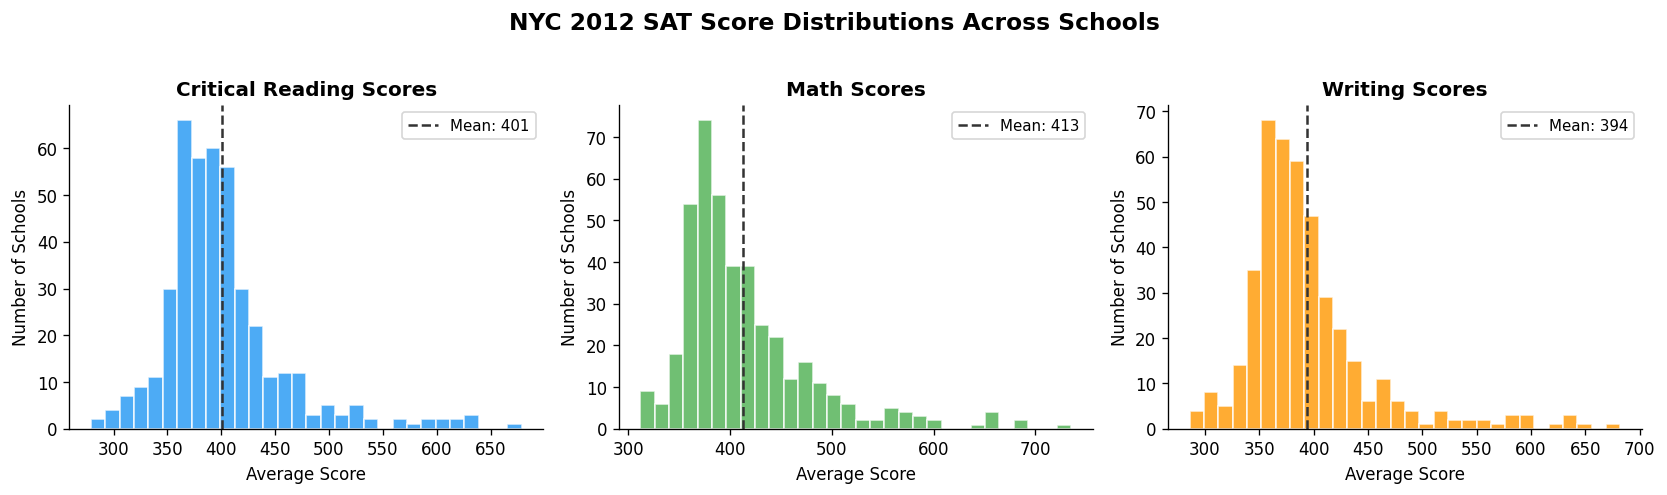

In [89]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# plotting a histogram for each subject
for ax, col, color, label in zip(axes,
        ['Reading', 'Math', 'Writing'],
        ['#2196F3', '#4CAF50', '#FF9800'],
        ['Critical Reading', 'Math', 'Writing']):
    ax.hist(df[col], bins=30, color=color, alpha=0.8, edgecolor='white')
    ax.axvline(df[col].mean(), color='#333', linestyle='--', linewidth=1.5,
               label=f'Mean: {df[col].mean():.0f}')
    ax.set_title(f'{label} Scores', fontsize=12, fontweight='bold')
    ax.set_xlabel('Average Score')
    ax.set_ylabel('Number of Schools')
    ax.legend(fontsize=9)

fig.suptitle('NYC 2012 SAT Score Distributions Across Schools', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


### 3.2 Distribution of Test Takers (School Size)


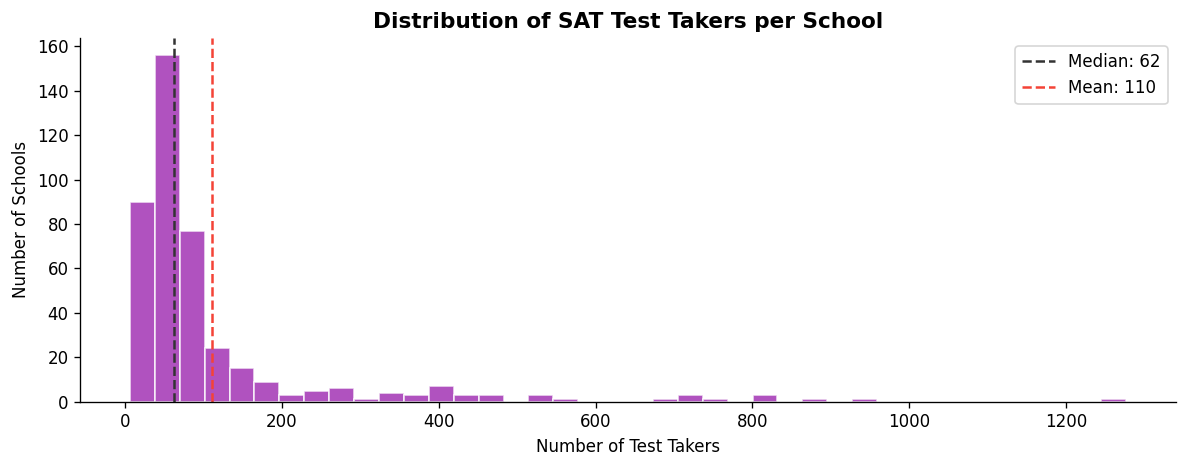

In [90]:
# the test-taker distribution tells us about school size, worth checking separately
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(df['NumTakers'], bins=40, color='#9C27B0', alpha=0.8, edgecolor='white')
ax.axvline(df['NumTakers'].median(), color='#333', linestyle='--', linewidth=1.5,
           label=f'Median: {df["NumTakers"].median():.0f}')
ax.axvline(df['NumTakers'].mean(), color='#F44336', linestyle='--', linewidth=1.5,
           label=f'Mean: {df["NumTakers"].mean():.0f}')
ax.set_title('Distribution of SAT Test Takers per School', fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Test Takers')
ax.set_ylabel('Number of Schools')
ax.legend()
plt.tight_layout()
plt.show()


### 3.3 Correlation Heatmap


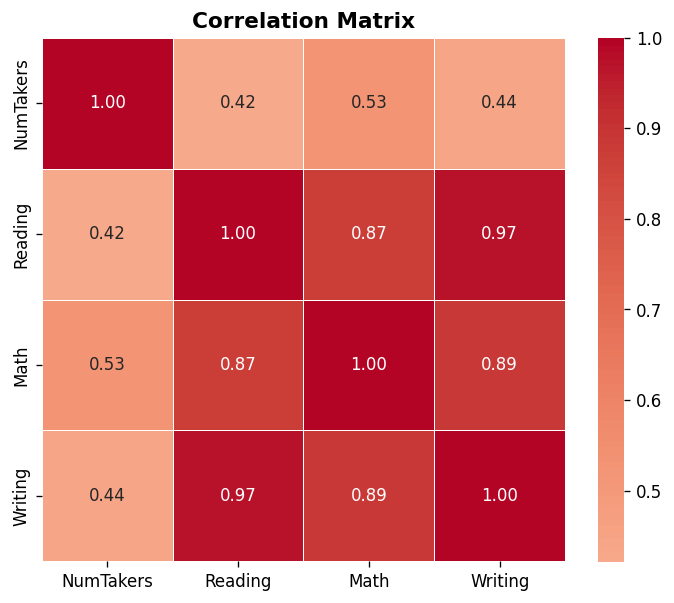

In [91]:
# want to see how correlated the three score variables are, and whether school size matters
fig, ax = plt.subplots(figsize=(6, 5))
corr = df[['NumTakers', 'Reading', 'Math', 'Writing']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, ax=ax, linewidths=0.5)
ax.set_title('Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 4. Standardisation (Feature Scaling)

From the lectures, PCA is sensitive to the scale of the data and K-Means uses Euclidean distance, so we need to standardise first. Otherwise a feature like NumTakers (which ranges from 6–1277) would completely dominate over the score features (which are all in the 300–700 range). StandardScaler makes each feature have mean=0 and std=1.


In [92]:
features = ['NumTakers', 'Reading', 'Math', 'Writing']
X = df[features].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# sanity check — means should be ~0 and stds ~1
print(f'means after scaling: {X_scaled.mean(axis=0).round(4)}')
print(f'stds after scaling:  {X_scaled.std(axis=0).round(4)}')


means after scaling: [ 0. -0. -0.  0.]
stds after scaling:  [1. 1. 1. 1.]


## 5. K-Means Clustering

K-Means needs us to decide k before running it, and it assumes the clusters are roughly spherical. To pick a good k, I'll use:
- The **Elbow Method** : inertia drops as we increase k
- **Internal indices** :(Silhouette, Calinski-Harabasz, Davies-Bouldin) 

### 5.1 Selecting k


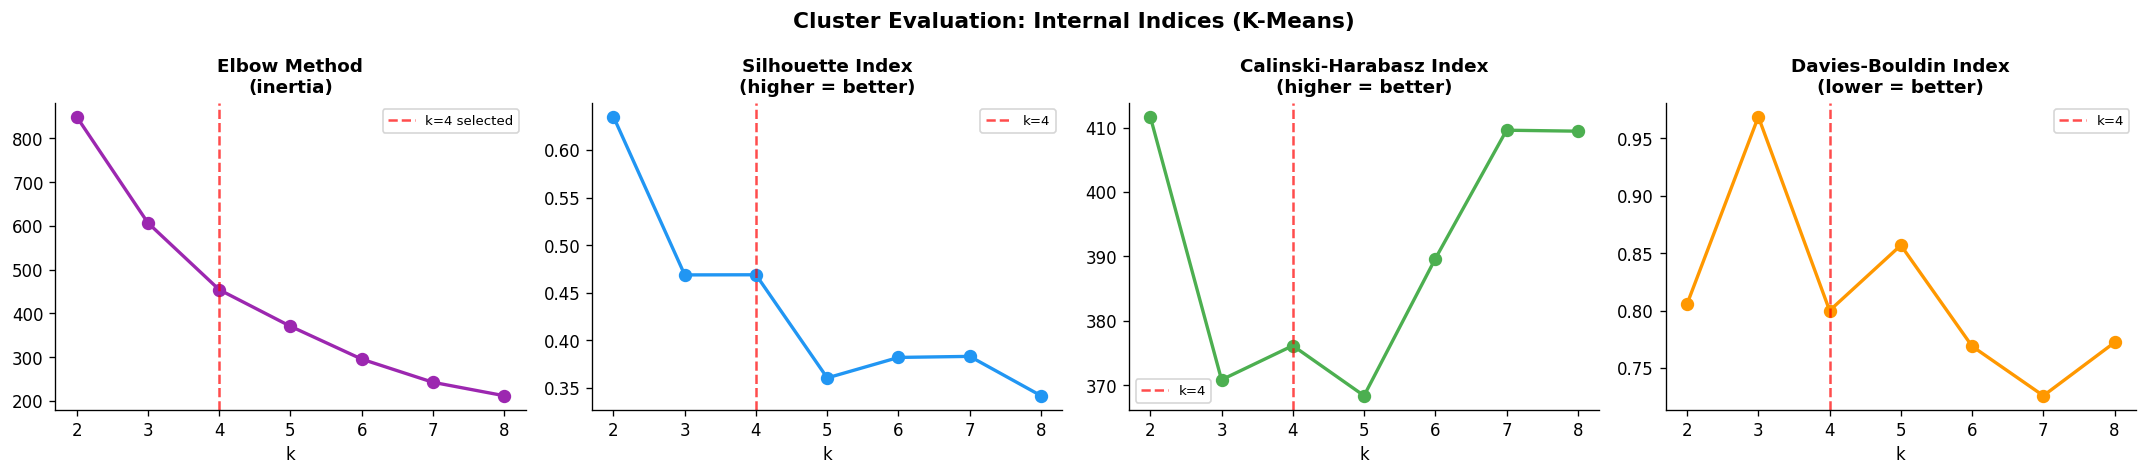


Scores for k=4:
  Silhouette:        0.469  (range -1 to 1, higher is better)
  Calinski-Harabasz: 376.2  (higher is better)
  Davies-Bouldin:    0.800  (closer to 0 is better)


In [93]:
ks = list(range(2, 9))
inertias, sil_list, ch_list, db_list = [], [], [], []

for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    lbl = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_list.append(silhouette_score(X_scaled, lbl))
    ch_list.append(calinski_harabasz_score(X_scaled, lbl))  # higher = better separated
    db_list.append(davies_bouldin_score(X_scaled, lbl))     # lower = better

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

axes[0].plot(ks, inertias, 'o-', color='#9C27B0', linewidth=2, markersize=7)
axes[0].axvline(4, color='red', linestyle='--', alpha=0.7, label='k=4 selected')
axes[0].set_title('Elbow Method\n(inertia)', fontsize=11, fontweight='bold')
axes[0].set_xlabel('k')
axes[0].legend(fontsize=8)

axes[1].plot(ks, sil_list, 'o-', color='#2196F3', linewidth=2, markersize=7)
axes[1].axvline(4, color='red', linestyle='--', alpha=0.7, label='k=4')
axes[1].set_title('Silhouette Index\n(higher = better)', fontsize=11, fontweight='bold')
axes[1].set_xlabel('k')
axes[1].legend(fontsize=8)

axes[2].plot(ks, ch_list, 'o-', color='#4CAF50', linewidth=2, markersize=7)
axes[2].axvline(4, color='red', linestyle='--', alpha=0.7, label='k=4')
axes[2].set_title('Calinski-Harabasz Index\n(higher = better)', fontsize=11, fontweight='bold')
axes[2].set_xlabel('k')
axes[2].legend(fontsize=8)

axes[3].plot(ks, db_list, 'o-', color='#FF9800', linewidth=2, markersize=7)
axes[3].axvline(4, color='red', linestyle='--', alpha=0.7, label='k=4')
axes[3].set_title('Davies-Bouldin Index\n(lower = better)', fontsize=11, fontweight='bold')
axes[3].set_xlabel('k')
axes[3].legend(fontsize=8)

fig.suptitle('Cluster Evaluation: Internal Indices (K-Means)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# print scores for k=4 specifically
print('\nScores for k=4:')
print(f'  Silhouette:        {sil_list[2]:.3f}  (range -1 to 1, higher is better)')
print(f'  Calinski-Harabasz: {ch_list[2]:.1f}  (higher is better)')
print(f'  Davies-Bouldin:    {db_list[2]:.3f}  (closer to 0 is better)')


### 5.2 Silhouette Chart for k=4

The silhouette plot shows how well each individual school fits within its cluster. I remember from the lecture that you want the shape to look like a "cigar", wide and uniform rather than a pointy knife shape. A pointy shape means some schools in that cluster don't really belong there.


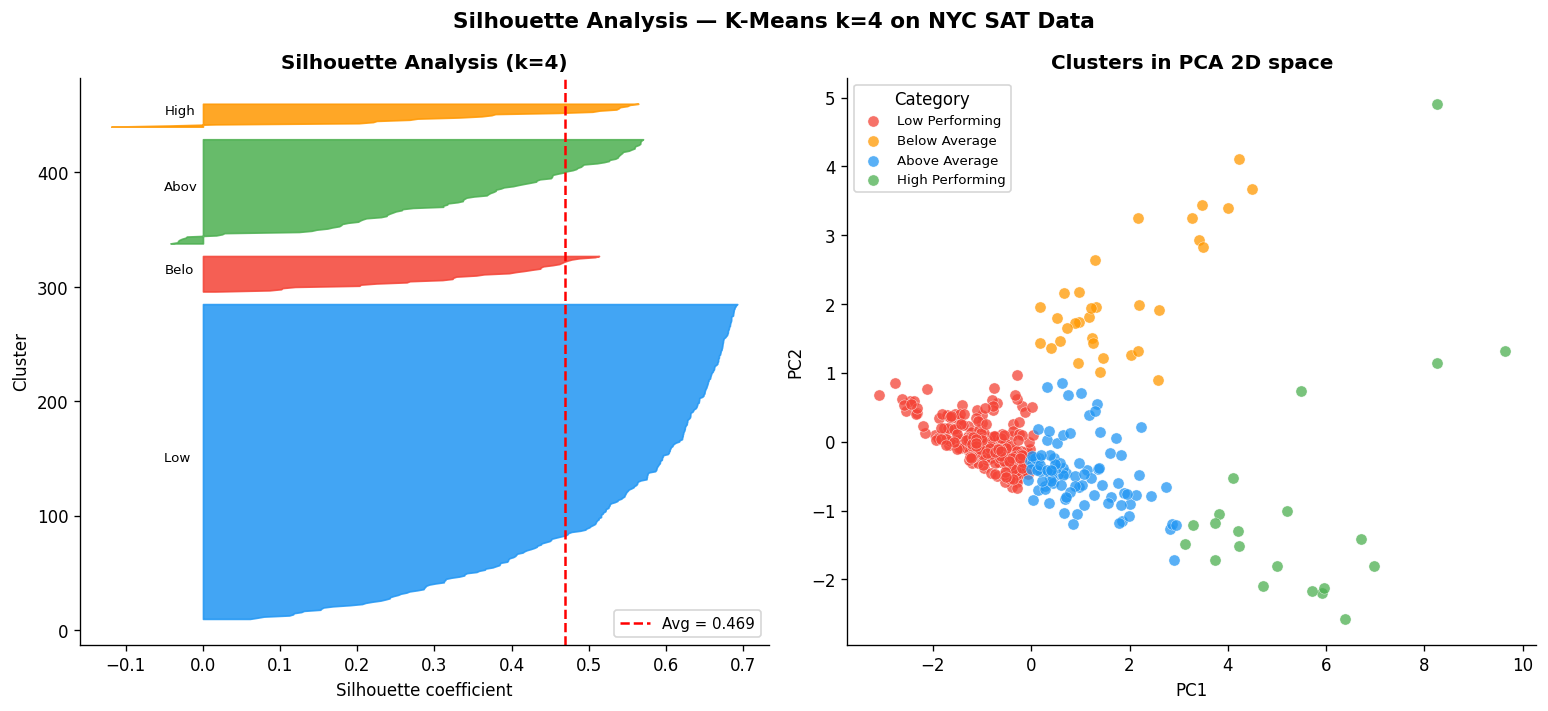

In [94]:
K = 4
km = KMeans(n_clusters=K, random_state=42, n_init=10)
cluster_labels = km.fit_predict(X_scaled)
sil_vals = silhouette_samples(X_scaled, cluster_labels)
avg_sil  = silhouette_score(X_scaled, cluster_labels)

# sort clusters by average score so labels make sense (Low -> High)
cl_avg = {c: df['AvgScore'].values[cluster_labels == c].mean() for c in range(K)}
sorted_cl  = sorted(cl_avg, key=cl_avg.get)
cat_order  = ['Low Performing', 'Below Average', 'Above Average', 'High Performing']
cat_colors = {
    'Low Performing': '#F44336',
    'Below Average':  '#FF9800',
    'Above Average':  '#2196F3',
    'High Performing':'#4CAF50'
}
lmap = {c: l for c, l in zip(sorted_cl, cat_order)}
df['Category'] = pd.Series(cluster_labels).map(lmap).values

cluster_palette = [cat_colors[lmap[c]] for c in range(K)]

# quick PCA for visualisation 
pca_vis = PCA(n_components=2)
X2 = pca_vis.fit_transform(X_scaled)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 6))

y_lower = 10
for i, cl in enumerate(sorted_cl):
    vals = np.sort(sil_vals[cluster_labels == cl])
    y_upper = y_lower + vals.shape[0]
    ax1.fill_betweenx(np.arange(y_lower, y_upper), 0, vals,
                      facecolor=cluster_palette[i], edgecolor=cluster_palette[i], alpha=0.85)
    ax1.text(-0.05, y_lower + 0.5 * vals.shape[0], cat_order[i][:4], fontsize=8)
    y_lower = y_upper + 10

ax1.axvline(avg_sil, color='red', linestyle='--', linewidth=1.5,
            label=f'Avg = {avg_sil:.3f}')
ax1.set_xlabel('Silhouette coefficient')
ax1.set_ylabel('Cluster')
ax1.set_title('Silhouette Analysis (k=4)', fontsize=12, fontweight='bold')
ax1.legend(fontsize=9)

for cat in cat_order:
    mask = df['Category'] == cat
    ax2.scatter(X2[mask, 0], X2[mask, 1], c=cat_colors[cat], label=cat,
                alpha=0.75, s=45, edgecolors='white', linewidth=0.3)
ax2.set_xlabel('PC1')
ax2.set_ylabel('PC2')
ax2.set_title('Clusters in PCA 2D space', fontsize=12, fontweight='bold')
ax2.legend(fontsize=8, title='Category')

fig.suptitle('Silhouette Analysis — K-Means k=4 on NYC SAT Data', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


### 5.3 Cluster Profiles


In [95]:
print('schools per cluster:')
print(df['Category'].value_counts())
print('\ncluster averages:')
df.groupby('Category')[['NumTakers','Reading','Math','Writing','AvgScore']].mean().round(1)


schools per cluster:
Category
Low Performing     276
Above Average       92
Below Average       32
High Performing     21
Name: count, dtype: int64

cluster averages:


,NumTakers,Reading,Math,Writing,AvgScore
Category,,,,,
Above Average,97.4,436.5,450.9,429.8,439.0
Below Average,508.2,425.6,462.9,420.4,436.3
High Performing,278.2,577.4,609.9,583.2,590.2
Low Performing,55.7,372.7,380.2,364.6,372.5


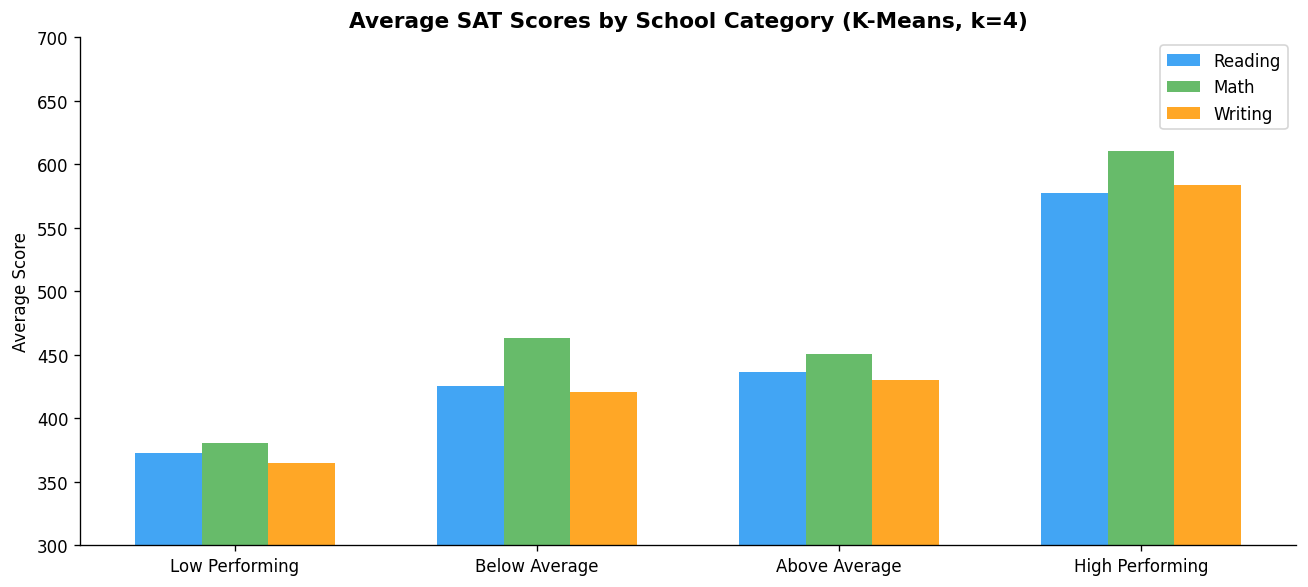

In [96]:
# bar chart comparing average scores per cluster
summary = df.groupby('Category')[['Reading','Math','Writing']].mean().loc[cat_order]
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(cat_order))
width = 0.22

for i, (col, color) in enumerate(zip(['Reading','Math','Writing'], ['#2196F3','#4CAF50','#FF9800'])):
    ax.bar(x + i*width, summary[col], width, label=col, color=color, alpha=0.85)

ax.set_title('Average SAT Scores by School Category (K-Means, k=4)', fontsize=13, fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels(cat_order, fontsize=10)
ax.set_ylabel('Average Score')
ax.legend()
ax.set_ylim(300, 700)
plt.tight_layout()
plt.show()


## 6. DBSCAN — Density-Based Clustering

One limitation of K-Means is that we have to tell it how many clusters to find, and it also forces every point into a cluster even if it doesn't really belong anywhere. DBSCAN tho looks for dense regions and anything that doesn't fit into a dense group gets labelled as noise (outlier). That's actually useful here because some schools might just be genuinely weird/unusual rather than fitting into a neat category.

DBSCAN has two main parameters I will be using:
- **eps** : how close two points need to be to be considered neighbours
- **min_samples** : minimum number of neighbours a point needs to count as a "core" point


DBSCAN results (eps=0.6, min_samples=5):
  Clusters found: 1
  Core samples:   386
  Noise points:   26  <- schools that dont fit any dense group


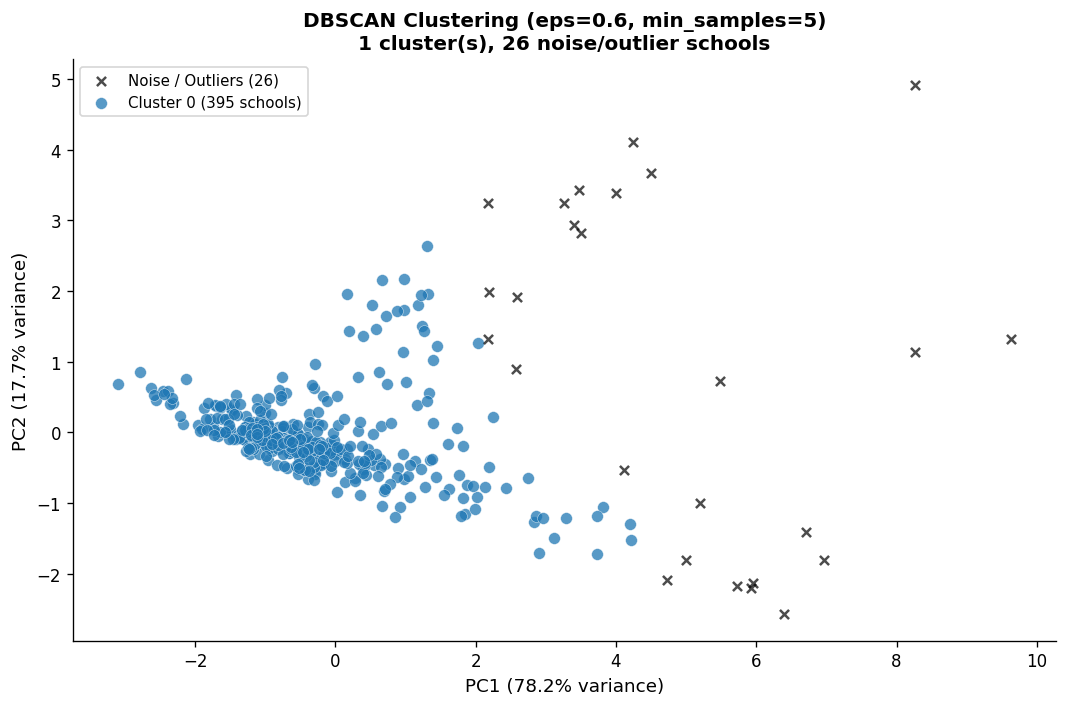


The 26 noise schools are ones DBSCAN couldnt assign to any cluster.
These could be very unusual schools worth looking at individually.


In [97]:
# running DBSCAN on the 2D PCA projection
pca_db = PCA(n_components=2)
X_pca_db = pca_db.fit_transform(X_scaled)

db = DBSCAN(eps=0.6, min_samples=5)
db_labels = db.fit_predict(X_pca_db)

n_clusters_db = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise       = np.sum(db_labels == -1)
n_core        = len(db.core_sample_indices_)

print(f'DBSCAN results (eps=0.6, min_samples=5):')
print(f'  Clusters found: {n_clusters_db}')
print(f'  Core samples:   {n_core}')
print(f'  Noise points:   {n_noise}  <- schools that dont fit any dense group')

fig, ax = plt.subplots(figsize=(9, 6))
cmap = plt.get_cmap('tab10')

for lbl in sorted(set(db_labels)):
    mask = db_labels == lbl
    if lbl == -1:
        # noise points shown as black X marks
        ax.scatter(X_pca_db[mask, 0], X_pca_db[mask, 1], c='black', s=30,
                   marker='x', label=f'Noise / Outliers ({mask.sum()})', alpha=0.7, zorder=5)
    else:
        ax.scatter(X_pca_db[mask, 0], X_pca_db[mask, 1], c=[cmap(lbl)], s=50,
                   label=f'Cluster {lbl} ({mask.sum()} schools)',
                   alpha=0.75, edgecolors='white', linewidth=0.3)

ax.set_xlabel('PC1 (78.2% variance)', fontsize=11)
ax.set_ylabel('PC2 (17.7% variance)', fontsize=11)
ax.set_title(f'DBSCAN Clustering (eps=0.6, min_samples=5)\n'
             f'{n_clusters_db} cluster(s), {n_noise} noise/outlier schools',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9, loc='upper left')
plt.tight_layout()
plt.show()

print(f'\nThe {n_noise} noise schools are ones DBSCAN couldnt assign to any cluster.')
print('These could be very unusual schools worth looking at individually.')


## 7. PCA — Dimensionality Reduction

PCA is a feature extraction method. The idea is to find new axes (principal components) that capture the most variance in the data, then project everything onto those axes. This reduces the number of dimensions while keeping as much information as possible.

A key thing to remember (from the PCA lecture) is that PCA is sensitive to scale, so we need to standardise the data first, which we already did.

### 7.1 Fit PCA and Check Explained Variance


In [98]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
df['PC1'] = X_pca[:, 0]
df['PC2'] = X_pca[:, 1]

var_exp = pca.explained_variance_ratio_ * 100
print(f'PC1: {var_exp[0]:.1f}% of variance')
print(f'PC2: {var_exp[1]:.1f}% of variance')
print(f'Total retained: {sum(var_exp):.1f}%')

print('\nLoadings (how much each feature contributes to each component):')
loadings_df = pd.DataFrame(
    pca.components_.T,
    index=['NumTakers','Reading','Math','Writing'],
    columns=['PC1','PC2']
).round(3)
print(loadings_df)


PC1: 78.2% of variance
PC2: 17.7% of variance
Total retained: 95.9%

Loadings (how much each feature contributes to each component):
             PC1    PC2
NumTakers  0.354  0.924
Reading    0.539 -0.280
Math       0.537 -0.074
Writing    0.544 -0.251


### 7.2 Scree Plot


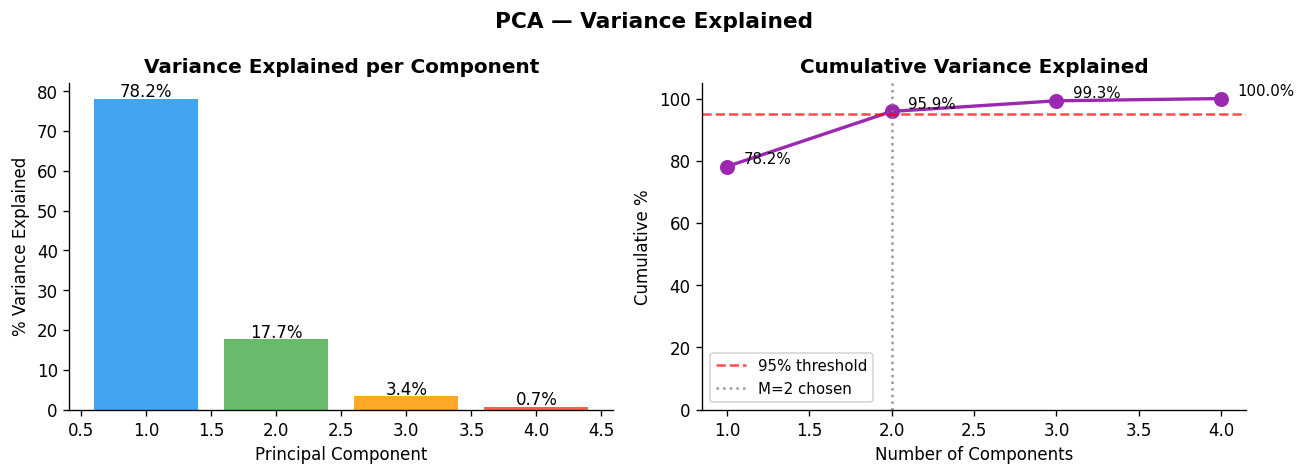

In [99]:
pca_full = PCA(n_components=4)
pca_full.fit(X_scaled)
var_all = pca_full.explained_variance_ratio_ * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

ax1.bar(range(1, 5), var_all, color=['#2196F3','#4CAF50','#FF9800','#F44336'], alpha=0.85)
ax1.set_title('Variance Explained per Component', fontsize=12, fontweight='bold')
ax1.set_xlabel('Principal Component')
ax1.set_ylabel('% Variance Explained')
for i, v in enumerate(var_all):
    ax1.text(i+1, v+0.5, f'{v:.1f}%', ha='center', fontsize=10)

cum_var = np.cumsum(var_all)
ax2.plot(range(1, 5), cum_var, 'o-', color='#9C27B0', linewidth=2, markersize=8)
ax2.axhline(95, color='red', linestyle='--', alpha=0.7, label='95% threshold')
ax2.axvline(2, color='gray', linestyle=':', alpha=0.8, label='M=2 chosen')
ax2.set_title('Cumulative Variance Explained', fontsize=12, fontweight='bold')
ax2.set_xlabel('Number of Components')
ax2.set_ylabel('Cumulative %')
ax2.legend(fontsize=9)
ax2.set_ylim(0, 105)
for i, v in enumerate(cum_var):
    ax2.text(i+1+0.1, v+1, f'{v:.1f}%', fontsize=9)

fig.suptitle('PCA — Variance Explained', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


### 7.3 PCA Biplot


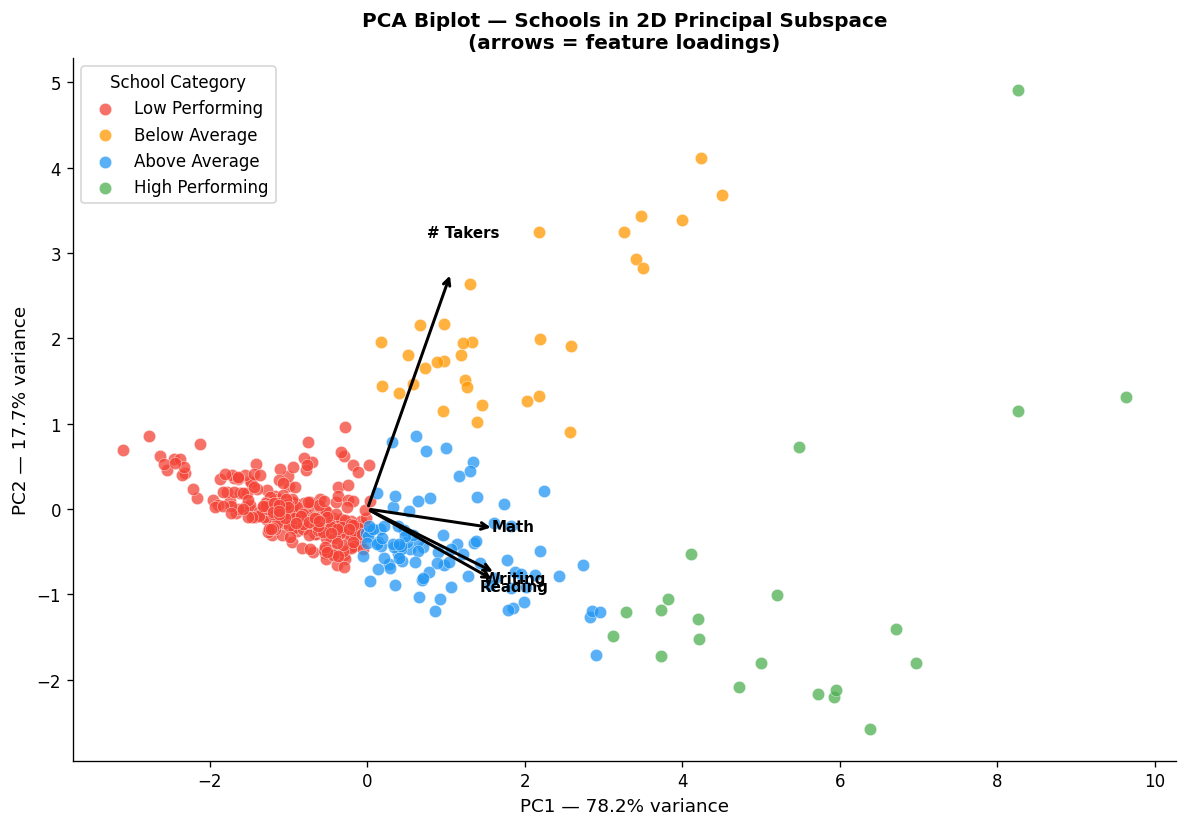

In [100]:
fig, ax = plt.subplots(figsize=(10, 7))

for cat in cat_order:
    mask = df['Category'] == cat
    ax.scatter(df.loc[mask, 'PC1'], df.loc[mask, 'PC2'],
               c=cat_colors[cat], label=cat, alpha=0.75, s=55,
               edgecolors='white', linewidth=0.3)

ax.set_xlabel(f'PC1 — {var_exp[0]:.1f}% variance', fontsize=11)
ax.set_ylabel(f'PC2 — {var_exp[1]:.1f}% variance', fontsize=11)
ax.set_title('PCA Biplot — Schools in 2D Principal Subspace\n(arrows = feature loadings)',
             fontsize=12, fontweight='bold')
ax.legend(title='School Category', fontsize=10)

# draw loading arrows to show which features pull in which direction
loadings = pca.components_.T
feat_labels = ['# Takers', 'Reading', 'Math', 'Writing']
scale = 3
for i, feat in enumerate(feat_labels):
    ax.annotate('', xy=(loadings[i, 0]*scale, loadings[i, 1]*scale),
                xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color='black', lw=1.8))
    ax.text(loadings[i, 0]*scale*1.15, loadings[i, 1]*scale*1.15,
            feat, fontsize=9, ha='center', color='black', fontweight='bold')

plt.tight_layout()
plt.show()


## 8. Top / Bottom Schools Summary


In [101]:
print('=== TOP 5 SCHOOLS (High Performing cluster) ===')
top5 = df[df['Category']=='High Performing'][['School','AvgScore','NumTakers']] \
         .sort_values('AvgScore', ascending=False).head(5)
print(top5.to_string(index=False))

print('\n=== BOTTOM 5 SCHOOLS (Low Performing cluster) ===')
bot5 = df[df['Category']=='Low Performing'][['School','AvgScore','NumTakers']] \
         .sort_values('AvgScore').head(5)
print(bot5.to_string(index=False))


=== TOP 5 SCHOOLS (High Performing cluster) ===
                                           School   AvgScore  NumTakers
                           STUYVESANT HIGH SCHOOL 698.666667        832
                     BRONX HIGH SCHOOL OF SCIENCE 656.333333        731
              STATEN ISLAND TECHNICAL HIGH SCHOOL 651.000000        227
HIGH SCHOOL OF AMERICAN STUDIES AT LEHMAN COLLEGE 640.000000         92
                      TOWNSEND HARRIS HIGH SCHOOL 636.666667        278

=== BOTTOM 5 SCHOOLS (Low Performing cluster) ===
                                       School   AvgScore  NumTakers
                    MULTICULTURAL HIGH SCHOOL 295.666667         29
INTERNATIONAL HIGH SCHOOL AT PROSPECT HEIGHTS 304.333333         71
        INTERNATIONAL SCHOOL FOR LIBERAL ARTS 311.333333         49
                HIGH SCHOOL OF WORLD CULTURES 313.000000         42
          INTERNATIONAL COMMUNITY HIGH SCHOOL 315.000000         34
